# REINFORCE: learn a stochastic policy from complete episodes

REINFORCE directly adjusts a policy $\pi_\theta(a\mid s)$ to make actions followed by large returns more likely. Its policy-gradient estimate is

$$
\nabla_\theta J(\theta) \approx \frac{1}{N}\sum_t G_t\nabla_\theta\log\pi_\theta(a_t\mid s_t),
$$

where $G_t=\sum_{k=0}^{T-t-1}\gamma^k r_{t+k+1}$ is the discounted reward-to-go. Unlike DQN, REINFORCE learns no action-value function and needs no replay buffer or target network.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

ENV_ID = "CartPole-v1"
TOTAL_TIMESTEPS = 20_000
LEARNING_RATE = 1e-2
GAMMA = 0.99
EPISODES_PER_UPDATE = 5
MAX_GRAD_NORM = 1.0
SEED = 0

np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
env = gym.make(ENV_ID)
observation_dim = int(np.prod(env.observation_space.shape))
action_dim = env.action_space.n

print(f"Observation size: {observation_dim}; actions: {action_dim}; device: {device}")

Observation size: 4; actions: 2; device: cuda


## 1. Parameterize a stochastic policy

The network outputs one **logit** per discrete action. A categorical distribution converts those unconstrained values into action probabilities. During training, sample from the distribution: this is both the policy and its exploration mechanism. During evaluation, choose its mode.

In [2]:
policy_network = nn.Sequential(
    nn.Flatten(),
    nn.Linear(observation_dim, 64),
    nn.ReLU(),
    nn.Linear(64, action_dim),
).to(device)
optimizer = torch.optim.Adam(policy_network.parameters(), lr=LEARNING_RATE)


def action_distribution(observations):
    observations = torch.as_tensor(
        observations, dtype=torch.float32, device=device
    )
    logits = policy_network(observations)
    return torch.distributions.Categorical(logits=logits)


def select_action(observation, deterministic=False):
    distribution = action_distribution(observations=np.atleast_2d(observation))
    action = distribution.probs.argmax(dim=-1) if deterministic else distribution.sample()
    return int(action.item())

## 2. Compute discounted reward-to-go

After an episode ends, walk backward through its rewards. The recurrence

$$G_t=r_{t+1}+\gamma G_{t+1}$$

computes every reward-to-go in one pass. There is no bootstrap term: REINFORCE waits for a complete Gymnasium episode, whether it ends through `terminated` or `truncated`.

In [3]:
def discounted_returns(rewards):
    returns = np.zeros(len(rewards), dtype=np.float32)
    reward_to_go = 0.0
    for step in reversed(range(len(rewards))):
        reward_to_go = rewards[step] + GAMMA * reward_to_go
        returns[step] = reward_to_go
    return returns

## 3. Turn returns into a policy-gradient update

For a batch of complete episodes, minimize the negative sampled objective

$$L(\theta)=-\frac{1}{N}\sum_t G_t\log\pi_\theta(a_t\mid s_t).$$

Standardizing returns within the batch does not change which actions receive above- or below-average reinforcement, and usually reduces gradient variance. The returns must be treated as fixed targets: gradients flow through the log probabilities only.

In [4]:
def update_policy(observations, actions, rewards):
    returns = discounted_returns(rewards)
    
    observations = torch.as_tensor(
        np.asarray(observations), dtype=torch.float32, device=device
    )
    actions = torch.as_tensor(actions, dtype=torch.int64, device=device)
    returns = torch.as_tensor(returns, dtype=torch.float32, device=device)
    normalized_returns = (returns - returns.mean()) / (
        returns.std(unbiased=False) + 1e-8
    )

    distribution = action_distribution(observations)
    log_probabilities = distribution.log_prob(actions)
    loss = -(log_probabilities * normalized_returns).mean()

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_network.parameters(), MAX_GRAD_NORM)
    optimizer.step()
    return loss.item()

## 4. Collect complete episodes and update

Store observations, actions, and rewards until an episode finishes. Convert that episode's rewards to returns and optimize after terminating the episode.

In [5]:
def train(total_timesteps):
    episode_return = 0.0
    episode_returns, losses = [], []
    observations, actions, rewards = [], [], []
    observation, _ = env.reset(seed=SEED)

    for step in range(1, total_timesteps + 1):
        action = select_action(observation)
        next_observation, reward, terminated, truncated, _ = env.step(action)
        
        observations.append(np.asarray(observation, dtype=np.float32))
        actions.append(action)
        rewards.append(float(reward))
        observation = next_observation

        if terminated or truncated:
            # Train at the end of each episode
            loss = update_policy(observations, actions, rewards)
            
            episode_return = sum(rewards)
            episode_returns.append(episode_return)
            losses.append(loss)
            observations, actions, rewards = [], [], []
            observation, _ = env.reset()

        print(
            f"\rStep {step}/{total_timesteps} | Episodes: {len(episode_returns)} | Episode Return: {episode_return}",
            end="",
        )

    env.close()
    return episode_returns, losses


episode_returns, losses = train(TOTAL_TIMESTEPS)
print(f"\nTrained for {len(episode_returns)} episodes.")

Step 20000/20000 | Episodes: 271 | Episode Return: 145.0
Trained for 271 episodes.


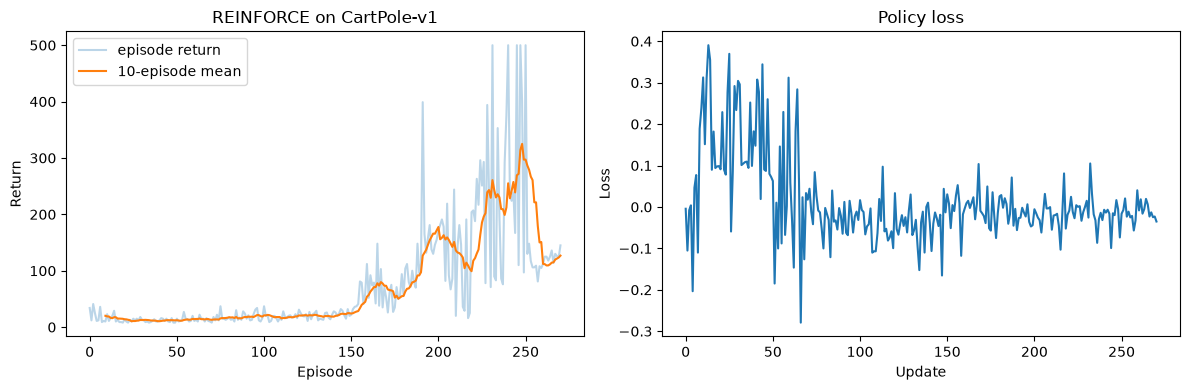

In [6]:
returns = np.asarray(episode_returns)
window = min(10, len(returns))
moving_average = np.convolve(
    returns, np.ones(window) / window, mode="valid"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(episode_returns, alpha=0.3, label="episode return")
axes[0].plot(
    np.arange(window - 1, len(returns)), moving_average, label=f"{window}-episode mean"
)
axes[0].set(title=f"REINFORCE on {ENV_ID}", xlabel="Episode", ylabel="Return")
axes[0].legend()
axes[1].plot(losses)
axes[1].set(title="Policy loss", xlabel="Update", ylabel="Loss")
plt.tight_layout()

## 5. Evaluate the modal policy

Training must remain stochastic, but evaluation can select the highest-probability action to measure the learned policy without sampling noise. Keep evaluation in a separate environment so it cannot disturb training state.

In [7]:
evaluation_env = gym.make(ENV_ID, render_mode="human")
evaluation_returns = []

for episode in range(5):
    observation, _ = evaluation_env.reset(seed=episode)
    episode_return = 0.0
    while True:
        with torch.no_grad():
            action = select_action(observation, deterministic=True)
        observation, reward, terminated, truncated, _ = evaluation_env.step(action)
        episode_return += reward
        if terminated or truncated:
            break
    evaluation_returns.append(episode_return)

evaluation_env.close()
print("Evaluation returns:", evaluation_returns)
print("Mean evaluation return:", np.mean(evaluation_returns))

Evaluation returns: [167.0, 161.0, 153.0, 151.0, 141.0]
Mean evaluation return: 154.6
